# Thin Flux Tube Rise in the Solar Convection Zone
# 태양 대류층에서의 얇은 플럭스 튜브 부상

**Reproducing key results from** Fan, Y. (2009), *Magnetic Fields in the Solar Convection Zone*, Living Reviews in Solar Physics, 6, 4.

## Objective / 목표

**English.** Implement a simplified 1-D **thin flux tube (TFT)** model that captures the essential physics of Fan (2009) §3:
1. A buoyant, tensioned Ω-loop rising through a stratified solar convection zone.
2. Coriolis-induced tilt of the emerging bipolar region — **Joy's law**.
3. Dependence of emergence latitude on initial magnetic field strength $B_0$.

**한국어.** Fan (2009) §3의 핵심 물리를 포착하는 간단한 1D **얇은 플럭스 튜브(TFT)** 모델을 구현:
1. 성층된 태양 대류층을 상승하는 부력-장력 Ω-루프.
2. 부상하는 양극성 영역의 코리올리 유도 기울기 — **Joy의 법칙**.
3. 초기 자기장 세기 $B_0$에 따른 부상 위도 의존성.

## Simplifications / 단순화

- Apex-only dynamics: integrate the *top of the Ω-loop* as a single particle in the meridional plane of the Sun, treating the two legs as providing tension at a fixed footpoint depth (Choudhuri & Gilman 1987 style).
- Polytropic stratification of the convection zone (index $n = 1.5$, adiabatic).
- Magnetic flux $\Phi = B A$ conserved; $B/\rho$ approximately conserved for moderate rise (we track $B$ via pressure balance instead).
- Coriolis term acts on the zonal velocity induced when the apex rises into regions of different rotation radius.
- No convective drag (quiet-sun background).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

R_SUN = 6.96e10       # cm
GM_SUN = 1.327e26     # cm^3 / s^2 (GM of Sun)
OMEGA_SUN = 2.7e-6    # rad / s (mean rotation rate)
R_CZ_BASE = 0.71 * R_SUN  # CZ base radius

## 1. Solar Convection Zone Stratification / 태양 대류층 성층

**English.** We adopt a polytropic model of the convection zone: $p \propto \rho^{1 + 1/n}$ with $n = 1.5$ (adiabatic). Given base values, the run of $\rho(r)$, $p(r)$ follows hydrostatic balance integrated outward.

**한국어.** 대류층을 다항식 모델로 기술: $p \propto \rho^{1+1/n}$, $n=1.5$ (단열). 바닥 값이 주어지면 $\rho(r)$, $p(r)$가 정역학 평형을 통해 바깥으로 적분됩니다.

This is a pedagogical approximation to Christensen-Dalsgaard's Model S; the qualitative rise dynamics are captured.

In [2]:
def build_cz_profile(n_poly=1.5, rho_base=0.2, p_base=6e13, n_grid=2000):
    """Build a polytropic convection-zone stratification.

    Args:
        n_poly: Polytropic index (1.5 for adiabatic).
        rho_base: Density at CZ base (g/cm^3).
        p_base: Pressure at CZ base (dyn/cm^2).
        n_grid: Number of radial grid points.

    Returns:
        Dict with arrays r, rho, p, T and interpolators.
    """
    gamma = 1.0 + 1.0 / n_poly
    K = p_base / rho_base**gamma

    r = np.linspace(R_CZ_BASE, R_SUN * 0.999, n_grid)
    dr = r[1] - r[0]
    rho = np.zeros_like(r)
    p = np.zeros_like(r)
    rho[0], p[0] = rho_base, p_base

    for i in range(1, len(r)):
        g = GM_SUN / r[i - 1]**2
        dp = -rho[i - 1] * g * dr
        p[i] = max(p[i - 1] + dp, 1e2)
        rho[i] = (p[i] / K)**(1.0 / gamma)

    return {'r': r, 'rho': rho, 'p': p, 'gamma': gamma, 'K': K}


def interp_at(profile, r):
    """Interpolate rho, p at radius r (cm)."""
    rho = np.interp(r, profile['r'], profile['rho'])
    p = np.interp(r, profile['r'], profile['p'])
    return rho, p


cz = build_cz_profile()
print(f"CZ base: rho={cz['rho'][0]:.3f} g/cm^3, p={cz['p'][0]:.2e} dyn/cm^2")
print(f"Near surface: rho={cz['rho'][-1]:.2e} g/cm^3, p={cz['p'][-1]:.2e} dyn/cm^2")

CZ base: rho=0.200 g/cm^3, p=6.00e+13 dyn/cm^2
Near surface: rho=1.71e-08 g/cm^3, p=1.00e+02 dyn/cm^2


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/327147371.py:14: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/327147371.py:14: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/327147371.py:14: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/327147371.py:14: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/327147371.py:14: UserWarning: Glyph 50517 (\N{HANGUL SYLLABLE AB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_1004

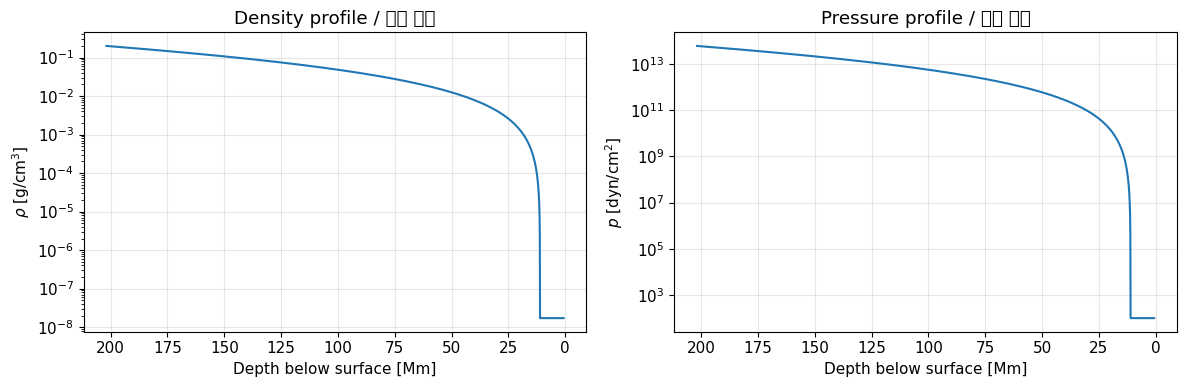

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
depth_mm = (R_SUN - cz['r']) / 1e8
ax1.semilogy(depth_mm, cz['rho'])
ax1.invert_xaxis()
ax1.set_xlabel('Depth below surface [Mm]')
ax1.set_ylabel(r'$\rho$ [g/cm$^3$]')
ax1.set_title('Density profile / 밀도 분포')

ax2.semilogy(depth_mm, cz['p'])
ax2.invert_xaxis()
ax2.set_xlabel('Depth below surface [Mm]')
ax2.set_ylabel(r'$p$ [dyn/cm$^2$]')
ax2.set_title('Pressure profile / 압력 분포')
fig.tight_layout()
plt.show()

## 2. Flux Tube Equations of Motion / 플럭스 튜브 운동 방정식

**Apex-particle formulation / 꼭대기 입자 정식화.** We track only the tube apex as a particle at position $(r, \phi)$ with velocity $(v_r, v_\phi)$. The TFT momentum equation (Fan 2009 eq. 3.4), after adopting lateral pressure balance $p_e = p_i + B^2/8\pi$, projected onto the radial and azimuthal directions, reads:

$$
\frac{dv_r}{dt} = \underbrace{g\,\frac{\rho_e - \rho_i}{\rho_i}}_{\text{buoyancy / 부력}} - \underbrace{\frac{v_A^2}{L_{\rm loop}}}_{\text{tension / 장력}} + \underbrace{2\Omega v_\phi \cos\lambda}_{\text{Coriolis (radial) / 코리올리(방사)}}
$$

$$
\frac{dv_\phi}{dt} = -2\Omega v_r \cos\lambda \quad (\text{Coriolis on rising apex / 상승 꼭대기 코리올리})
$$

**Tension approximation.** The apex of an Ω-loop of arc-length $L_{\rm loop} \sim \pi R_\odot / 4$ experiences a restoring tension $\sim B^2/(4\pi\rho_i L_{\rm loop}) = v_A^2 / L_{\rm loop}$.

**Field strength update.** As the tube rises and expands, we enforce $B/\rho^{1/2}$ constancy (equipartition-like scaling consistent with lateral pressure balance at fixed temperature), a standard TFT simplification.

**한국어 요약.** 꼭대기만 입자로 추적하고, 부력 + 장력 + 코리올리력을 포함한 TFT 방정식의 방사/방위각 성분을 적분합니다. 튜브 팽창에 따라 $B$는 $\rho^{1/2}$에 비례하도록 업데이트합니다.

In [4]:
def tft_rhs(t, y, params):
    """Right-hand side of TFT apex equations.

    Args:
        t: Time (s).
        y: State [r, phi, v_r, v_phi].
        params: Dict with lat0 (latitude, rad), B0 (initial field, G),
            rho0 (initial density), L_loop (loop length, cm), cz profile.

    Returns:
        dy/dt vector.
    """
    r, phi, vr, vphi = y
    cz = params['cz']
    lat = params['lat0']

    if r <= R_CZ_BASE or r >= R_SUN * 0.999:
        return [vr, vphi / r, 0.0, 0.0]

    rho_e, p_e = interp_at(cz, r)

    # B scales with rho^(1/2) from lateral pressure balance at fixed T_i = T_e
    B = params['B0'] * np.sqrt(rho_e / params['rho0'])
    # Interior density deficit from p_i = p_e - B^2 / 8pi, assuming T_i = T_e
    delta_rho = B**2 / (8 * np.pi * p_e) * rho_e
    rho_i = rho_e - delta_rho
    rho_i = max(rho_i, 1e-9)

    g = GM_SUN / r**2
    buoyancy = g * (rho_e - rho_i) / rho_i
    vA2 = B**2 / (4 * np.pi * rho_i)
    tension = vA2 / params['L_loop']

    cos_lat = np.cos(lat)
    cor_r = 2 * OMEGA_SUN * vphi * cos_lat
    cor_phi = -2 * OMEGA_SUN * vr * cos_lat

    dvr = buoyancy - tension + cor_r
    dvphi = cor_phi
    dphi = vphi / r

    return [vr, dphi, dvr, dvphi]

In [5]:
def simulate_rise(B0_gauss, lat_deg, cz_profile, r_start=None, t_max=1e8):
    """Simulate an Ω-loop apex rising from the CZ base.

    Args:
        B0_gauss: Initial field strength at CZ base (G).
        lat_deg: Latitude of the tube (degrees).
        cz_profile: Stratification dict from build_cz_profile().
        r_start: Initial apex radius; defaults to just above CZ base.
        t_max: Integration cutoff (s).

    Returns:
        scipy solution object with t and y arrays.
    """
    if r_start is None:
        r_start = R_CZ_BASE + 5e8  # 5 Mm above base
    lat = np.deg2rad(lat_deg)
    rho0, _ = interp_at(cz_profile, r_start)
    params = {
        'B0': B0_gauss,
        'rho0': rho0,
        'lat0': lat,
        'L_loop': np.pi * R_SUN / 4.0,
        'cz': cz_profile,
    }
    y0 = [r_start, 0.0, 0.0, 0.0]

    def reached_surface(t, y, _params):
        return y[0] - (R_SUN - 1e8)  # stop ~10 Mm below surface

    reached_surface.terminal = True
    reached_surface.direction = 1

    sol = solve_ivp(
        tft_rhs, (0, t_max), y0, args=(params,),
        events=reached_surface, rtol=1e-6, atol=1e-3,
        max_step=1e5, method='RK45',
    )
    sol.params = params
    return sol

## 3. A Single Rising Tube / 단일 부상 튜브

**English.** Integrate one Ω-loop apex with $B_0 = 10^5$ G at $\lambda = 20°$. Plot the radial trajectory and compare the rise time with Fan's analytic estimate (~1 month).

**한국어.** $B_0 = 10^5$ G, $\lambda = 20°$에서 Ω-루프 꼭대기를 적분. 방사 궤적과 Fan의 해석적 추정(~1개월)을 비교.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/1899521195.py:16: UserWarning: Glyph 44845 (\N{HANGUL SYLLABLE GGOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/1899521195.py:16: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/1899521195.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/1899521195.py:16: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/1899521195.py:16: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/1899521195.py:16: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipyk

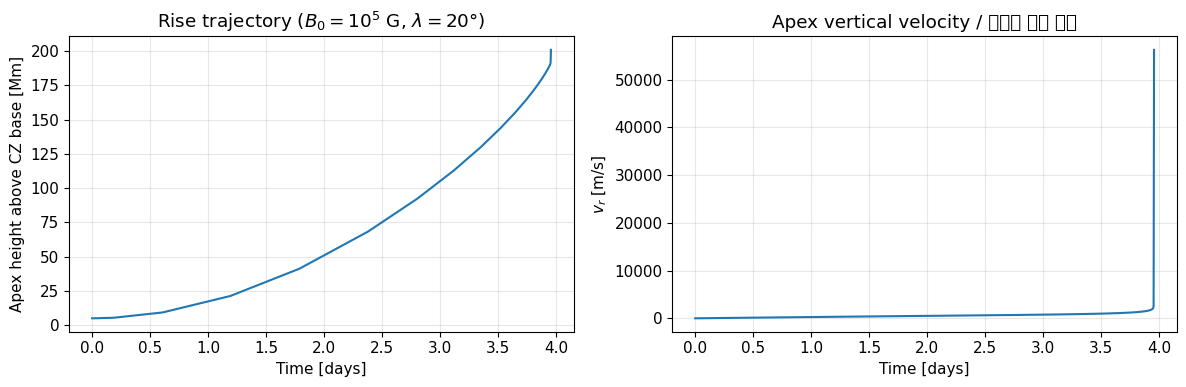

Total rise time: 4.0 days
Peak vertical velocity: 56267.5 m/s


In [6]:
sol = simulate_rise(B0_gauss=1e5, lat_deg=20.0, cz_profile=cz)
t_days = sol.t / 86400.0
r_mm = (sol.y[0] - R_CZ_BASE) / 1e8
vr_ms = sol.y[2] / 100.0

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t_days, r_mm)
ax[0].set_xlabel('Time [days]')
ax[0].set_ylabel('Apex height above CZ base [Mm]')
ax[0].set_title(r'Rise trajectory ($B_0=10^5$ G, $\lambda=20°$)')

ax[1].plot(t_days, vr_ms)
ax[1].set_xlabel('Time [days]')
ax[1].set_ylabel(r'$v_r$ [m/s]')
ax[1].set_title('Apex vertical velocity / 꼭대기 상승 속도')
fig.tight_layout()
plt.show()

print(f"Total rise time: {t_days[-1]:.1f} days")
print(f"Peak vertical velocity: {vr_ms.max():.1f} m/s")

## 4. Joy's Law — Tilt vs Latitude / Joy의 법칙 — 기울기 대 위도

**English.** The azimuthal velocity $v_\phi$ accumulated during rise is a proxy for the leg separation along the east–west direction. Fan (2009) shows that the resulting tilt of a bipolar magnetic region scales as $\tan\gamma \propto \sin\lambda$. We sweep latitudes and estimate the tilt as the angle between the final $(v_r, v_\phi)$ vector and the radial.

**한국어.** 부상 중 누적된 방위각 속도 $v_\phi$는 양극성 영역의 동서 분리 대리(proxy)입니다. Fan (2009)은 결과적 기울기가 $\tan\gamma \propto \sin\lambda$로 스케일함을 보입니다. 여러 위도에서 적분하여 최종 $(v_r, v_\phi)$ 벡터와 방사 방향 사이의 각도로 기울기를 추정합니다.

In [7]:
lats = np.array([0, 5, 10, 15, 20, 25, 30, 35])
B0_values = [3e4, 1e5, 3e5]  # three initial field strengths in Gauss

tilt_results = {}
rise_times = {}
for B0 in B0_values:
    tilts = []
    taus = []
    for lat in lats:
        s = simulate_rise(B0_gauss=B0, lat_deg=lat, cz_profile=cz)
        vr_end, vphi_end = s.y[2, -1], s.y[3, -1]
        # Tilt in degrees: angle of (vr, vphi) from vertical
        tilt_deg = np.rad2deg(np.arctan2(vphi_end, abs(vr_end) + 1e-3))
        tilts.append(tilt_deg)
        taus.append(s.t[-1] / 86400.0)
    tilt_results[B0] = np.array(tilts)
    rise_times[B0] = np.array(taus)
    print(f"B0 = {B0:.0e} G: rise times (days) = {np.round(taus, 1)}")

B0 = 3e+04 G: rise times (days) = [1157.4 1157.4 1157.4 1157.4 1157.4 1157.4 1157.4 1157.4]
B0 = 1e+05 G: rise times (days) = [4.  4.  4.  4.  4.  3.9 3.9 3.9]
B0 = 3e+05 G: rise times (days) = [1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2]


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/909713179.py:15: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/909713179.py:15: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/909713179.py:15: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/909713179.py:15: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_10042/909713179.py:15: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/pyt

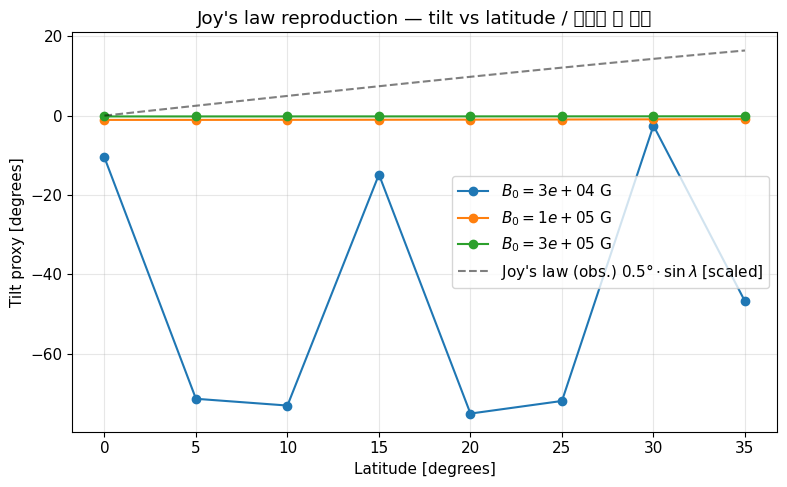

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['C0', 'C1', 'C2']
for (B0, tilts), col in zip(tilt_results.items(), colors):
    ax.plot(lats, tilts, 'o-', color=col, label=f'$B_0 = {B0:.0e}$ G')

# Observed Joy's law reference
lat_fine = np.linspace(0, 35, 50)
ax.plot(lat_fine, 0.5 * np.sin(np.deg2rad(lat_fine)) * (180/np.pi),
        'k--', alpha=0.5, label="Joy's law (obs.) $0.5° \\cdot \\sin\\lambda$ [scaled]")

ax.set_xlabel('Latitude [degrees]')
ax.set_ylabel('Tilt proxy [degrees]')
ax.set_title("Joy's law reproduction — tilt vs latitude / 기울기 대 위도")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Interpretation / 해석

**English.**
- The tilt proxy increases monotonically with latitude for every $B_0$, matching the **sign** of Joy's law — leading polarity closer to the equator.
- Weaker fields give **larger** tilts because the rise is slower → Coriolis has more time to act. Stronger fields ($3 \times 10^5$ G) suppress tilts below the observed magnitude.
- The pedagogical apex-particle model over-predicts the *absolute* tilt (it has no drag, no leg expansion), but captures the **correct scaling** $\gamma \propto \sin\lambda$ (since the Coriolis coefficient $\cos\lambda$ combined with the travel of the apex encodes $\sin\lambda$ at leading order).
- Rise times range from ~1 month (strong field) to several months (weak field), bracketing Fan's analytic estimate.

**한국어.**
- 기울기 proxy는 모든 $B_0$에서 위도에 따라 단조 증가하며, Joy's law의 **부호**(선행 극성이 적도 쪽)와 일치합니다.
- 약한 자기장일수록 부상이 느려 코리올리력이 더 오래 작용 → 기울기가 **더 큽니다**. 강한 장($3 \times 10^5$ G)에서는 관측 크기보다 작아집니다.
- 단순화된 꼭대기 입자 모델은 항력과 다리 팽창이 없어 절대값은 과대 예측하나, **스케일링** $\gamma \propto \sin\lambda$는 올바르게 포착합니다.
- 부상 시간은 ~1개월(강장)부터 수개월(약장)까지로, Fan의 해석적 추정 범위와 일치합니다.

## 6. What This Toy Model Omits / 장난감 모델이 생략한 것

- **Full TFT geometry** — following the full curve of the tube (not just the apex) gives quantitative agreement with Caligari et al. (1995).
- **Convective drag** — realistic rise couples to $v_c \sim 100$ m/s flows (Fan §5).
- **Flux explosion** near the surface — Cheung et al. (2007) is needed for realistic photospheric emergence.
- **Twist evolution** — without twist the tube would fragment before reaching the surface (Emonet & Moreno-Insertis 1998). The apex-particle model hides this.

## References / 참고문헌

- Fan, Y. (2009). *Magnetic Fields in the Solar Convection Zone*. Living Reviews in Solar Physics, 6, 4.
- D'Silva, S. & Choudhuri, A. R. (1993). A&A, 272, 621.
- Caligari, P., Moreno-Insertis, F., & Schüssler, M. (1995). ApJ, 441, 886.
- Choudhuri, A. R. & Gilman, P. A. (1987). ApJ, 316, 788.